(particles)=

# 粒子类的使用

`Gal3d` 使用 {py:class}`Particles <gal3d.point.Particles>` 类来管理和操作粒子数据。  

初始化时，需要提供粒子的坐标（``pos``）和质量（``mass``）。这里依然以TNG50-1中的一个星系的粒子数据为例。

In [1]:
import numpy as np
from AnastrisTNG import TNGsimulation


path = '/home/yxi/Simulation/sims/TNG50-1/output'
snap =99
snapshot = TNGsimulation.Snapshot(path,snap)

ID = 8 
sub = snapshot.load_particle(ID,order='star,gas')
sub.physical_units()
coor_trans = sub.face_on(alignwith='star',rmax=8)

pos = sub.s['pos'].view(np.ndarray)
mass = sub.s['mass'].view(np.ndarray)

使用 {py:class}`Particles <gal3d.point.Particles>` 类来初始化粒子的位置和质量信息。位置（`pos`）形状为`(N, 3)`，质量（`mass`）形状为`(N,)`，其中 `N` 是粒子的数量。

In [2]:
print(pos.shape)
print(mass.shape)

(624045, 3)
(624045,)


In [3]:
from gal3d.point import Particles

particles = Particles(pos=pos, mass=mass, 
                recenter=False, density_estimator='DensityEstimatorSPH')


- `recenter=False` 会保持粒子的原始位置，而不会将其重新居中（默认为 `True` ）。
- `density_estimator` 指定密度估计的方法，这里使用的是 `DensityEstimatorSPH`。可以使用 `Particles.available_estimators` 获取可用的密度估计器列表。

In [11]:
Particles.available_estimators()

['DensityEstimatorSPH']


``` {admonition} 关于密度估计器
使用 `DensityEstimatorSPH`，会调用 {py:class}`DensityEstimatorSPH <gal3d.point.density_estimator_plugins.estimator_sph.DensityEstimatorSPH>` 来进行密度估计，
{py:class}`DensityEstimatorSPH <gal3d.point.density_estimator_plugins.estimator_sph.DensityEstimatorSPH>` 是 {py:class}`DensityEstimatorBase <gal3d.point.density_estimator.DensityEstimatorBase>` 的子类。如果想要使用其他的密度估计方法，可以自定义一个类，继承自该类。只要你自定义了自己的一个密度估计器的类 继承自 `DensityEstimatorBase`，那么会自动注册到 `Particles.available_estimators` 中。

关于 `DensityEstimatorSPH`的实现原理，参见 {ref}`密度的估计 <density-estimator>`。
```

### 粒子属性

- {py:attr}`Particles.parameter <gal3d.point.Particles.parameter>` ：该粒子处的密度
- {py:attr}`Particles.hsm <gal3d.point.Particles.hsm>` ：该粒子处的平滑长度

In [12]:
print(particles.parameter)
print(particles.hsm)

[2.31941467e+10 1.91672209e+10 1.05705928e+10 ... 1.02048899e+00
 5.34523879e+00 2.23963342e-01]
[2.77080580e-02 3.04115883e-02 2.95638490e-02 ... 7.93721393e+01
 4.36944994e+01 1.28666636e+02]


### 查询任意位置的密度

使用 {py:meth}`Particles.get_parameter <gal3d.point.Particles.get_parameter>` 查询任意坐标的密度：

In [13]:
particles.get_parameter([1,2,3])

array([1735453.63173277])

### 2D密度投影


可用 {py:meth}`Particles.project_2d <gal3d.point.Particles.project_2d>` 获取粒子经过核函数（Kernel Function）平滑后的密度投影。


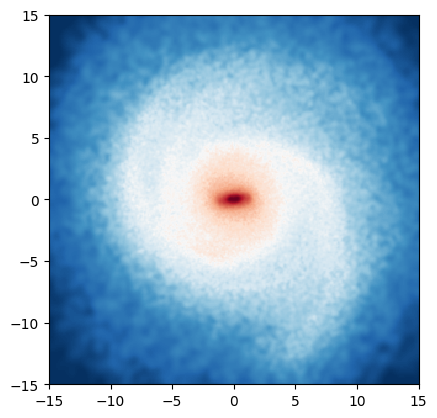

In [14]:
from gal3d.visualization.show import show_image

x_range = (-15, 15)
y_range = (-15, 15)
im = particles.project_2d(x_range=x_range, y_range=y_range, resolution=300)

show_image(im, cmap='RdBu_r')

平滑粒子法（SPH）常用于流体模拟，通过对粒子进行平滑处理，可以更好地捕捉流体的细节。下面以气体粒子为例，展示其密度分布：

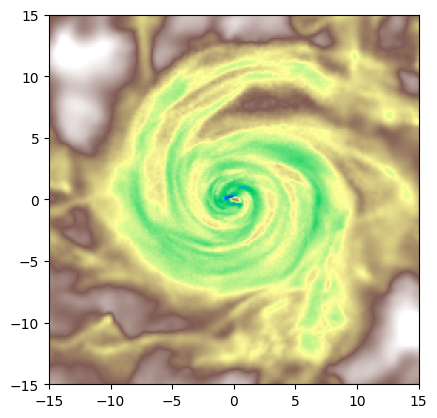

In [15]:
pos = sub.g['pos']
mass = sub.g['mass']

gas = Particles(pos=pos, mass=mass, recenter=False)

im= gas.project_2d(x_range=x_range, y_range=y_range, resolution=500)

show_image(im,cmap='terrain_r')


``` {seealso} 

`Gal3D` 对于 SPH 投影的实现 使用了 二次采样和再归一化的方法。在 {ref}`SPH 投影 <SPH-render2d>` 中有更详细的介绍和示例。

```

### 获取任意半径处的形状

可以使用 {py:meth}`Particles.shape_at <gal3d.point.Particles.shape_at>` 获取任意半径处的形状。该方法默认使用密度场版本的椭球形状迭代方法（{py:class}`EllipsoidalShapeEstimator <gal3d.model_workflow.fit_workflow_plugins.iterate_ellipsoid_continuous.IterateEllipsoidDensity>`）来估计形状。



In [4]:
particles.shape_at(2)[0]

<StructureCore|
   Coord : <RotateOnly|: (
        ang1  = -0.016 ± 3.880e-04  [-3.142, 3.142]
        ang2  = -0.007 ± 2.783e-04  [-1.571, 1.571]
        ang3  = 3.136 ± 3.090e-04  [-3.142, 3.142]
      )|>
   Geom  : <Ellipsoid|: (
        a       = 2.000  [0.100, inf]
        eps_ab  = 0.376 ± 5.305e-06  [0.001, 0.999]
        eps_bc  = 0.579 ± 7.562e-05  [0.001, 0.999]
      )|>
|>

In [31]:
res = particles.shape_at(np.geomspace(0.6, 20, 100))

Fitting radii: 100%|██████████| 100/100 [00:26<00:00,  3.78it/s]


In [32]:
res

ModelResult | num=100 | RotateOnly | Ellipsoid | N/A
─────────────────────────────────────────────────────────────────────────────────────
 #   cost          ang1          ang2          ang3       a       eps_ab       eps_bc
─────────────────────────────────────────────────────────────────────────────────────
 0  0.008  -0.099±0.000  -0.009±0.001   3.137±0.002   0.600  0.554±0.000  0.584±0.002
 1  0.001  -0.099±0.000  -0.004±0.000   3.130±0.000   0.622  0.544±0.000  0.574±0.000
 2  0.001  -0.132±0.001  -0.015±0.000   3.137±0.001   0.644  0.515±0.000  0.530±0.000
 3  0.001  -0.118±0.002  -0.009±0.000   3.138±0.000   0.667  0.501±0.000  0.527±0.000
 4  0.001  -0.100±0.000  -0.011±0.000   3.132±0.000   0.691  0.493±0.000  0.491±0.000
⋮     ⋮         ⋮             ⋮             ⋮          ⋮          ⋮            ⋮     
95  0.001   0.834±0.027  -0.026±0.006  -3.137±0.006  17.358  0.083±0.000  0.700±0.000
96  0.019  -2.157±0.075  -0.025±0.006  -3.133±0.011  17.984  0.050±0.001  0.701±0.003
97  0.001  -2.033±0.170  -0.024±0.001   3.134±0.001  18.632  0.046±0.000  0.688±0.000
98  0.003   0.812±0.232  -0.018±0.009   3.132±0.001  19.304  0.026±0.002  0.674±0.001
99  0.012   0.647±0.376  -0.014±0.009   3.130±0.012  20.000  0.023±0.005  0.662±0.003
─────────────────────────────────────────────────────────────────────────────────────
[100 rows × 6 parameters]  —  head(n) / tail(n) to select rows

Text(0, 0.5, 'Ellipticity')

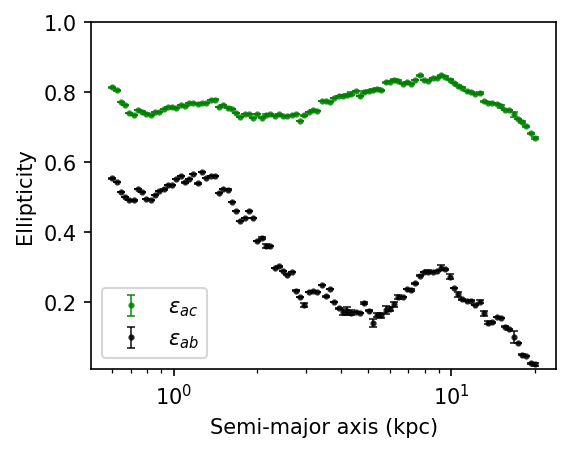

In [33]:
import matplotlib.pyplot as plt
fg,ax = plt.subplots(figsize=(4,3),dpi=150)

res.errorbar("a","eps_ac",ax=ax,c="g")
res.errorbar("a","eps_ab",ax=ax,c="k")
ax.set_xscale("log")
ax.legend()
ax.set_ylim(0.01,1)
ax.set_xlabel("Semi-major axis (kpc)")
ax.set_ylabel("Ellipticity")
